In [1]:
#!sudo python3 -m pip install pyarrow fastparquet
#!sudo python3 -m pip install "pandas==2.1.4" "pyarrow==14.0.2"

In [2]:
# これを一番最初に実行
import pyarrow as pa

try:
    pa.unregister_extension_type("pandas.period")
except:
    pass

try:
    pa.unregister_extension_type("arrow.py_extension_type")
except:
    pass

In [3]:
data_path = '/workspace/data/default/train/0000.parquet'

import pandas as pd
df = pd.read_parquet(data_path)
print(df.head())

# 列名を表示する
print(df.columns)

                                               video
0  {'bytes': b'\x00\x00\x00 ftypisom\x00\x00\x02\...
1  {'bytes': b'\x00\x00\x00 ftypisom\x00\x00\x02\...
2  {'bytes': b'\x00\x00\x00 ftypisom\x00\x00\x02\...
3  {'bytes': b'\x00\x00\x00 ftypisom\x00\x00\x02\...
4  {'bytes': b'\x00\x00\x00 ftypisom\x00\x00\x02\...
Index(['video'], dtype='object')


In [4]:
import os
import pandas as pd
import cv2

out_dir = "/workspace/data/default/train/videos"
csv_path = f"{out_dir}/metadata.csv"
os.makedirs(out_dir, exist_ok=True)

df_out = []

for i, row in df.iterrows():
    print(f"Processing row {i} / {len(df)} ...")
    
    video_bytes = row["video"]["bytes"]
    mp4_path = f"{out_dir}/{i}.mp4"
    
    # 保存
    with open(mp4_path, "wb") as f:
        f.write(video_bytes)

    # OpenCVで読み込み
    cap = cv2.VideoCapture(mp4_path)

    if not cap.isOpened():
        print(f"Failed to open {mp4_path}")
        continue

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    duration = frame / fps if fps > 0 else 0

    cap.release()

    df_out.append({
        "video_path": mp4_path,
        "frame": frame,
        "fps": fps,
        "duration": duration,
        "width": width,
        "height": height
    })

df_out = pd.DataFrame(df_out)
df_out.to_csv(csv_path, index=False)

Processing row 0 / 100 ...
Processing row 1 / 100 ...
Processing row 2 / 100 ...
Processing row 3 / 100 ...
Processing row 4 / 100 ...
Processing row 5 / 100 ...
Processing row 6 / 100 ...
Processing row 7 / 100 ...
Processing row 8 / 100 ...
Processing row 9 / 100 ...
Processing row 10 / 100 ...
Processing row 11 / 100 ...
Processing row 12 / 100 ...
Processing row 13 / 100 ...
Processing row 14 / 100 ...
Processing row 15 / 100 ...
Processing row 16 / 100 ...
Processing row 17 / 100 ...
Processing row 18 / 100 ...
Processing row 19 / 100 ...
Processing row 20 / 100 ...
Processing row 21 / 100 ...
Processing row 22 / 100 ...
Processing row 23 / 100 ...
Processing row 24 / 100 ...
Processing row 25 / 100 ...
Processing row 26 / 100 ...
Processing row 27 / 100 ...
Processing row 28 / 100 ...
Processing row 29 / 100 ...
Processing row 30 / 100 ...
Processing row 31 / 100 ...
Processing row 32 / 100 ...
Processing row 33 / 100 ...
Processing row 34 / 100 ...
Processing row 35 / 100 ...
Pr

                                   video_path  frame     fps  duration  width  \
0  /workspace/data/default/train/videos/0.mp4    125  25.000  5.000000   1920   
1  /workspace/data/default/train/videos/1.mp4    125  25.000  5.000000   1920   
2  /workspace/data/default/train/videos/2.mp4    120  23.976  5.005005   1920   
3  /workspace/data/default/train/videos/3.mp4    120  23.976  5.005005   1920   
4  /workspace/data/default/train/videos/4.mp4    150  29.970  5.005005   1920   

   height  
0    1080  
1    1080  
2    1080  
3    1080  
4    1080  


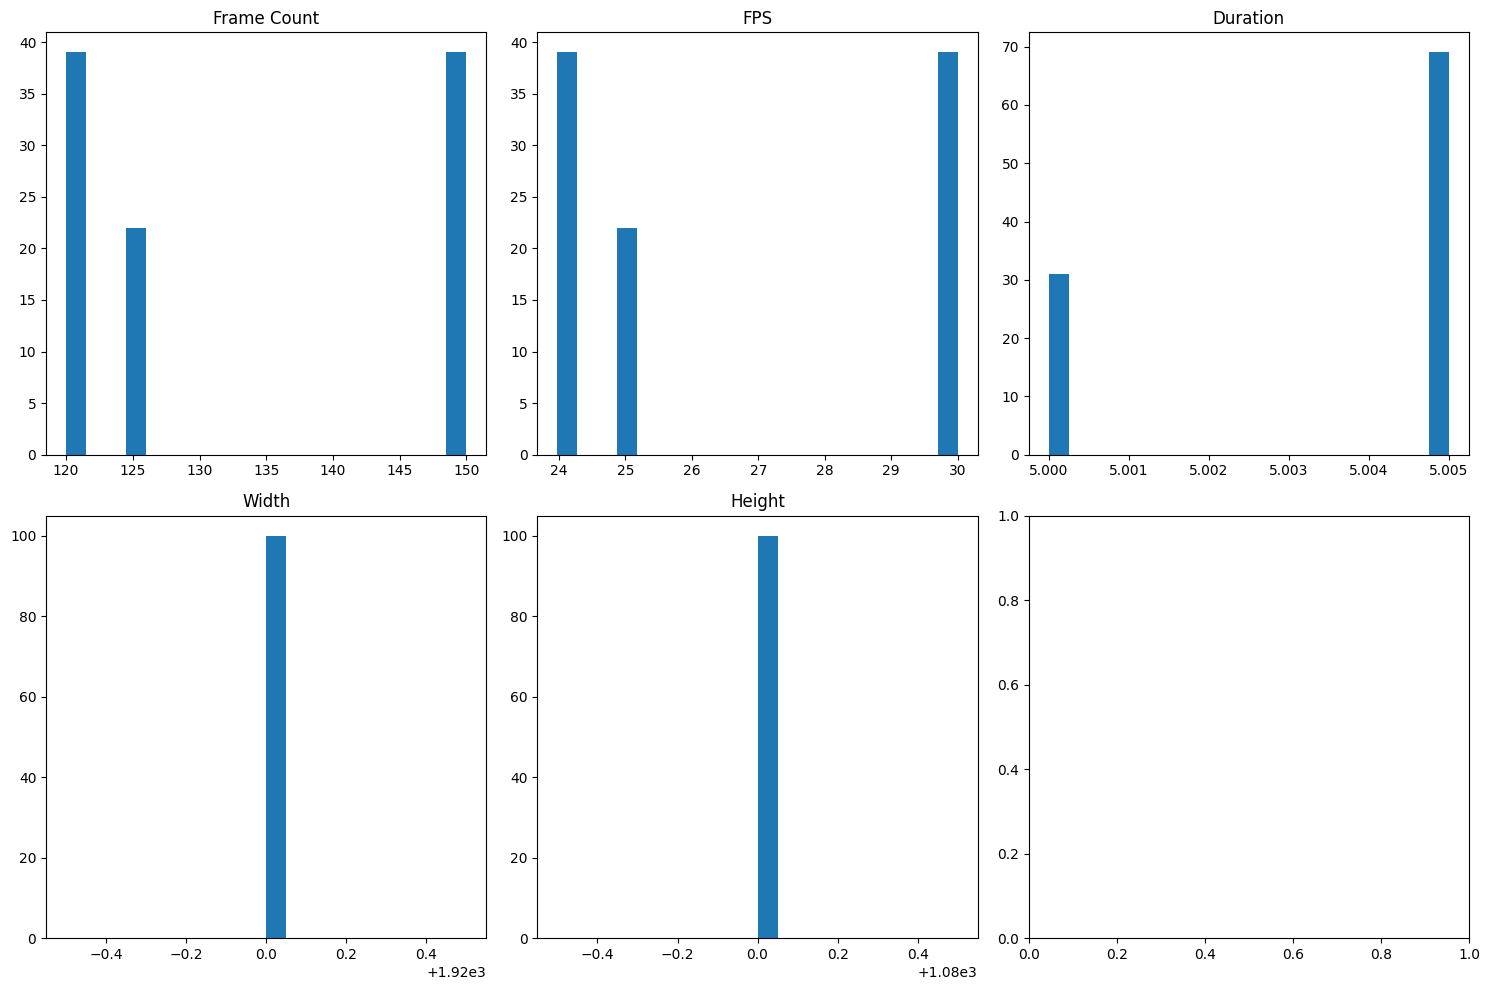

In [5]:
# csv を出力して、統計情報を可視化する, frame, fps, duration, width, height などの統計情報を可視化する
df_csv = pd.read_csv(csv_path)
print(df_csv.head())

import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].hist(df_csv["frame"], bins=20)
axes[0, 0].set_title("Frame Count")
axes[0, 1].hist(df_csv["fps"], bins=20)
axes[0, 1].set_title("FPS")
axes[0, 2].hist(df_csv["duration"], bins=20)
axes[0, 2].set_title("Duration")
axes[1, 0].hist(df_csv["width"], bins=20)
axes[1, 0].set_title("Width")
axes[1, 1].hist(df_csv["height"], bins=20)
axes[1, 1].set_title("Height")
plt.tight_layout()
plt.show()

In [8]:
!sudo python3 -m pip install datasets huggingface_hub mlcroissant

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 35.7 MB/s  0:00:00
  Created wheel for jsonpath-rw: filename=jsonpath_rw-1.4.0-py3-none-any.whl size=15176 sha256=68cbe50f31f144c3f680f1c55e6c980af15023b5456c70590d77106a6de682eb
  Stored in directory: /tmp/pip-ephem-wheel-cache-1lggmd42/wheels/e3/76/6f/c25be6a9e6cc9985b96e8c95997d46790242c6426ef68e754c
Successfully built jsonpath-rw
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [mlcroissant] [mlcroissant]


In [13]:
from mlcroissant import Dataset

ds = Dataset(jsonld="https://huggingface.co/api/datasets/xiangbog/Generic-Instructional-Video-Editing-Challenge-Dataset/croissant")
records = ds.records("default")

  -  [Metadata(Generic-Instructional-Video-Editing-Challenge-Dataset)] Property "http://mlcommons.org/croissant/citeAs" is recommended, but does not exist.
  -  [Metadata(Generic-Instructional-Video-Editing-Challenge-Dataset)] Property "https://schema.org/datePublished" is recommended, but does not exist.
  -  [Metadata(Generic-Instructional-Video-Editing-Challenge-Dataset)] Property "https://schema.org/license" is recommended, but does not exist.
  -  [Metadata(Generic-Instructional-Video-Editing-Challenge-Dataset)] Property "https://schema.org/version" is recommended, but does not exist.


In [14]:
from datasets import load_dataset

ds = load_dataset("xiangbog/Generic-Instructional-Video-Editing-Challenge-Dataset")

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating train split: 100%|██████████| 100/100 [00:00<00:00, 27114.25 examples/s]


In [17]:
ds

DatasetDict({
    train: Dataset({
        features: ['video'],
        num_rows: 100
    })
})

In [27]:
print(ds['train'].features)
print(ds['train'].num_rows)
print(ds['train'].features['video'])

{'video': Video(decode=True, stream_index=None, dimension_order='NCHW', num_ffmpeg_threads=1, device='cpu', seek_mode='exact')}
100
Video(decode=True, stream_index=None, dimension_order='NCHW', num_ffmpeg_threads=1, device='cpu', seek_mode='exact')
